In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [2]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
from lifelines import CoxPHFitter

In [3]:
####################################################
## Kaplan Meiers ##
####################################################

In [4]:
# For BCMO Survival STATUS (OS)

In [5]:
def kaplan_meier_plots(
    clinical_file,
    expr_file,
    genes,
    output_file,
    split_method="median",
    fig_title=None,
    time_col="OS.from.sampling"
):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.statistics import logrank_test

    # Text size configuration
    TITLE_SIZE = 26       # subplot titles
    FIG_TITLE_SIZE = 32   # figure-wide title
    LABEL_SIZE = 16       # x/y labels
    TICK_SIZE = 14        # tick labels
    LEGEND_SIZE = 14      # legend

    # 1. Load clinical data
    clinical = pd.read_csv(clinical_file)
    clinical = clinical.rename(columns={"died": "Status"})
    
    # 2. Load expression/activity matrix
    expr = pd.read_csv(expr_file, index_col=0)
    
    # 3. Fixed 2x2 grid
    n_cols = 2
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 14))
    axes = axes.flatten()
    
    # 4. Figure-wide title
    if fig_title is None:
        title_map = {
            "median": "Survival Analysis of BCMO for ALL Genes -- ACTIVITY",
            "quartile": "Survival Analysis of BCMO for Quartile Genes (Activity)"
        }
        fig_title = title_map.get(split_method, "Survival Analysis")
    fig.suptitle(fig_title, fontsize=FIG_TITLE_SIZE, y=1.02)
    
    # 5. Loop through genes (max 4 for 2x2 grid)
    for i, gene in enumerate(genes[:4]):
        ax = axes[i]
        
        if gene not in expr.index:
            ax.text(0.5, 0.5, f"{gene} not found", ha='center', va='center', fontsize=TITLE_SIZE)
            ax.axis('off')
            continue
        
        # Extract gene activity
        gene_activity = expr.loc[gene].rename("Activity")
        
        # Merge with clinical data
        df = clinical.merge(gene_activity, left_on="Sample_ID", right_index=True)
        
        # Define High/Low groups
        if split_method == "median":
            df[f"{gene}_group"] = (df["Activity"] > df["Activity"].median()).map({True: "High", False: "Low"})
            df_to_use = df
        elif split_method == "quartile":
            q_low = df["Activity"].quantile(0.25)
            q_high = df["Activity"].quantile(0.75)
            df_to_use = df[(df["Activity"] <= q_low) | (df["Activity"] >= q_high)].copy()
            df_to_use[f"{gene}_group"] = df_to_use["Activity"].apply(lambda x: "High" if x >= q_high else "Low")
        else:
            raise ValueError("split_method must be 'median' or 'quartile'")
        
        # Kaplan–Meier plot
        kmf = KaplanMeierFitter()
        for group, grouped_df in df_to_use.groupby(f"{gene}_group"):
            kmf.fit(grouped_df[time_col], grouped_df["Status"], label=group)
            kmf.plot_survival_function(ax=ax, ci_show=True)
        
        # Log-rank test
        high = df_to_use[df_to_use[f"{gene}_group"] == "High"]
        low = df_to_use[df_to_use[f"{gene}_group"] == "Low"]
        results = logrank_test(
            high[time_col], low[time_col],
            event_observed_A=high["Status"], event_observed_B=low["Status"]
        )
        pval = results.p_value

        # Compute hazard ratio with CoxPH
        df_cph = df_to_use[[time_col, "Status", f"{gene}_group"]].copy()
        df_cph[f"{gene}_group"] = df_cph[f"{gene}_group"].map({"Low": 0, "High": 1})
        cph = CoxPHFitter()
        try:
            cph.fit(df_cph, duration_col=time_col, event_col="Status")
            hr = cph.hazard_ratios_[f"{gene}_group"]
        except Exception:
            hr = float("nan")
        
        # Format values
        if pval >= 0.005:
            pval_str = f"{pval:.4f}"
        else:
            pval_str = f"{pval:.1e}".replace("e-0", "e-").replace("e", "×10")
        hr_str = f"{hr:.2f}" if not np.isnan(hr) else "NA"
        
        # Set subplot title and labels
        gene_clean = gene.replace("_NC", "")
        ax.set_title(f"{gene_clean} (HR={hr_str}, p={pval_str})", fontsize=TITLE_SIZE)
        ax.set_xlabel(f"Time from Sampling ({time_col})", fontsize=LABEL_SIZE)
        ax.set_ylabel("Overall Survival Probability", fontsize=LABEL_SIZE)
        ax.tick_params(axis='both', labelsize=TICK_SIZE)
        ax.legend(fontsize=LEGEND_SIZE)
    
    # Remove unused axes if fewer than 4 genes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()


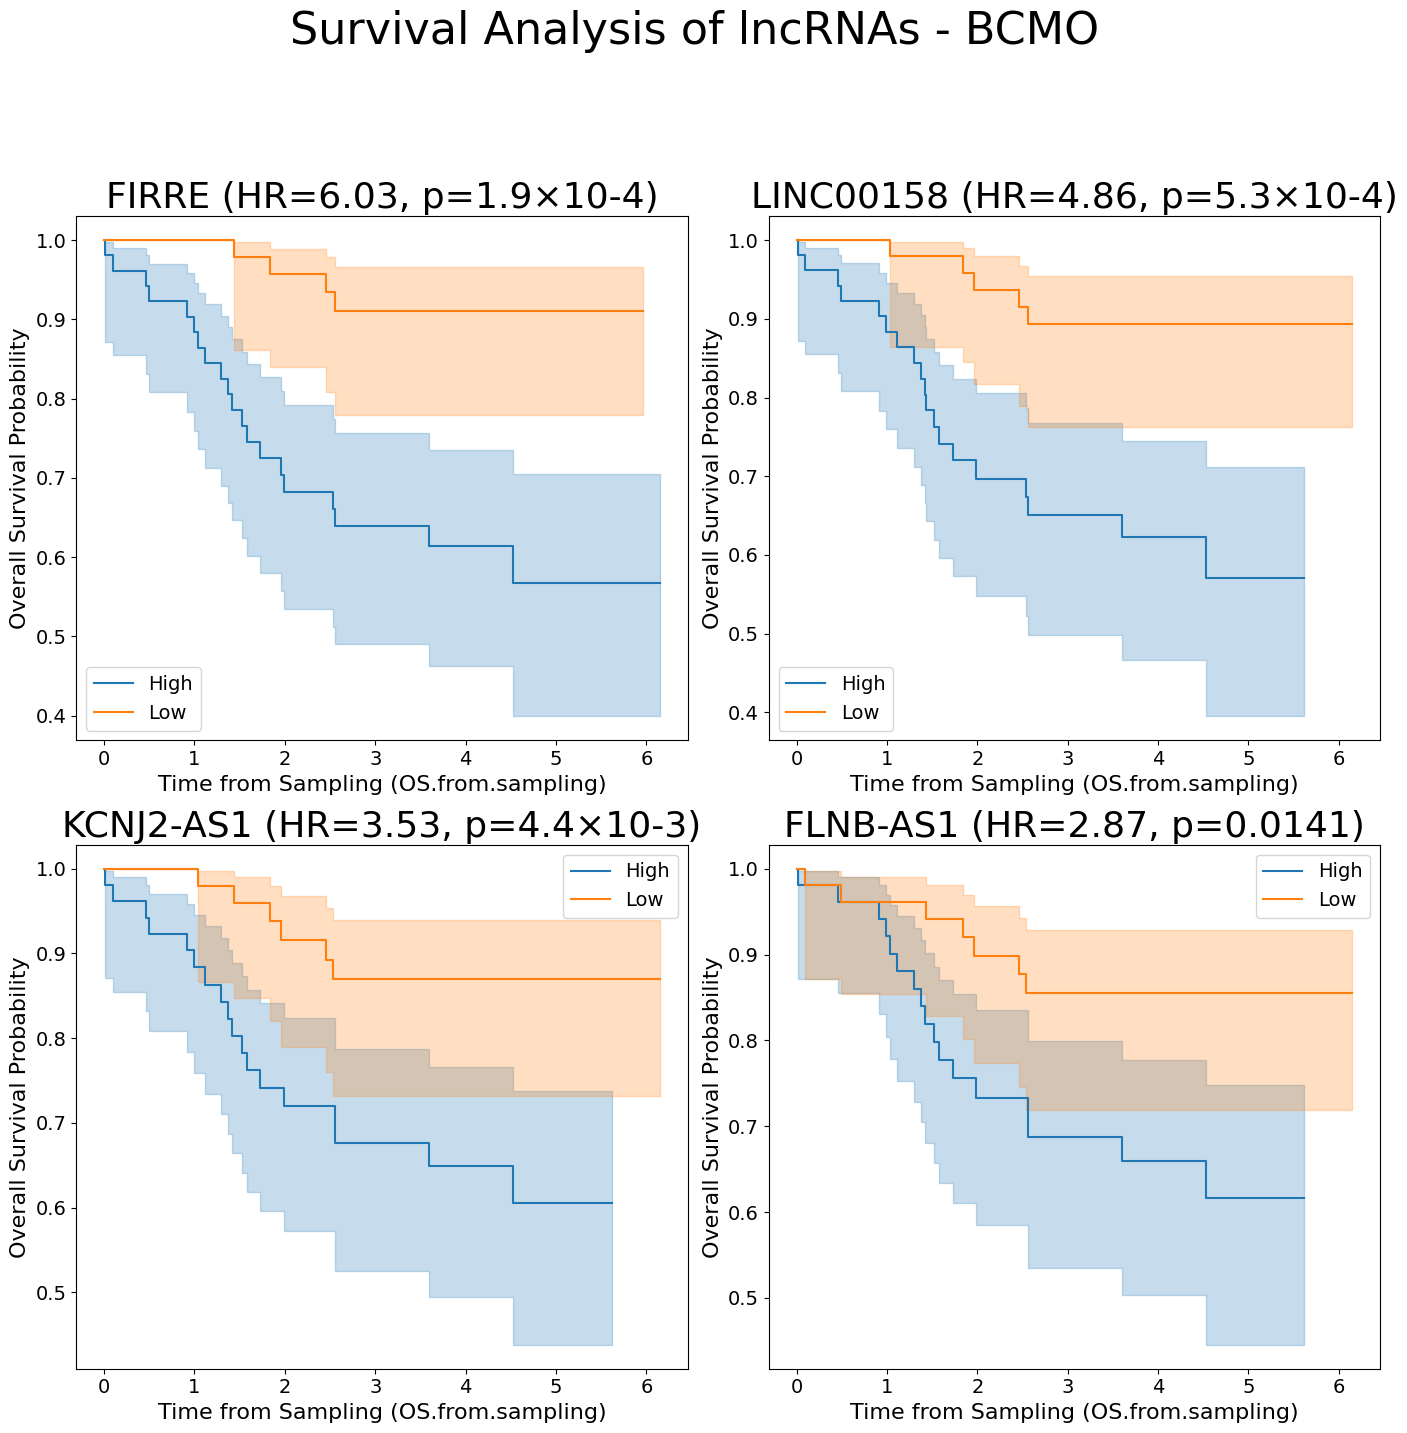

In [6]:
# Activity BCMO with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../../data/BCMO/clinical_info.csv",
    expr_file="../../../data/BCMO/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_all_genes_BCMO_activity.png",
    split_method="median",
    fig_title="Survival Analysis of lncRNAs - BCMO",
    time_col="OS.from.sampling"
)

In [7]:
# For ICGC Survival STATUS (OS)

In [8]:
def kaplan_meier_plots(
    clinical_file,
    expr_file,
    genes,
    output_file,
    split_method="median",
    fig_title=None,
    time_col="OS.from.sampling"
):
    """
    Generate Kaplan-Meier survival plots with hazard ratios for a list of genes.

    Parameters:
    - clinical_file: path to clinical CSV (must have Sample_ID and Status)
    - expr_file: path to expression/activity CSV (genes x samples)
    - genes: list of gene names to analyze
    - output_file: path to save the figure
    - split_method: "median" or "quartile"
    - fig_title: string for the figure-wide title (optional)
    - time_col: name of the time column in clinical data
    """
    # 1. Load clinical data
    clinical = pd.read_csv(clinical_file)
    clinical = clinical.dropna(subset=['donor_vital_status', 'donor_survival_time'])
    clinical['donor_vital_status'] = clinical['donor_vital_status'].map({'alive': 0, 'deceased': 1})
    clinical = clinical.rename(columns={"donor_vital_status": "Status", "Sample_ID": "Samples"})
    
    # 2. Load expression/activity matrix
    expr = pd.read_csv(expr_file, index_col=0)
    
    # 3. Determine subplot grid size dynamically
    n_cols = 2
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 7 * n_rows))
    axes = axes.flatten()
    
    # 4. Figure-wide title
    if fig_title is None:
        title_map = {
            "median": "Survival Analysis of ICGC for ALL Genes -- ACTIVITY",
            "quartile": "Survival Analysis of ICGC for Quartile Genes (Activity)"
        }
        fig_title = title_map.get(split_method, "Survival Analysis")
    fig.suptitle(fig_title, fontsize=30, y=1.02)
    
    # 5. Loop through genes
    for i, gene in enumerate(genes):
        ax = axes[i]
        
        if gene not in expr.index:
            ax.text(0.5, 0.5, f"{gene} not found", ha='center', va='center', fontsize=14)
            ax.axis('off')
            continue
        
        # Extract gene activity
        gene_activity = expr.loc[gene].rename("Activity")
        
        # Merge with clinical data
        df = clinical.merge(gene_activity, left_on="Samples", right_index=True)
        
        # Define High/Low groups
        if split_method == "median":
            df[f"{gene}_group"] = (df["Activity"] > df["Activity"].median()).map({True: "High", False: "Low"})
            df_to_use = df
        elif split_method == "quartile":
            q_low = df["Activity"].quantile(0.25)
            q_high = df["Activity"].quantile(0.75)
            df_to_use = df[(df["Activity"] <= q_low) | (df["Activity"] >= q_high)].copy()
            df_to_use[f"{gene}_group"] = df_to_use["Activity"].apply(lambda x: "High" if x >= q_high else "Low")
        else:
            raise ValueError("split_method must be 'median' or 'quartile'")
        
        # Kaplan–Meier plot
        kmf = KaplanMeierFitter()
        for group, grouped_df in df_to_use.groupby(f"{gene}_group"):
            kmf.fit(grouped_df[time_col], grouped_df["Status"], label=group)
            kmf.plot_survival_function(ax=ax, ci_show=True)
        
        # Log-rank test
        high = df_to_use[df_to_use[f"{gene}_group"] == "High"]
        low = df_to_use[df_to_use[f"{gene}_group"] == "Low"]
        results = logrank_test(
            high[time_col], low[time_col],
            event_observed_A=high["Status"], event_observed_B=low["Status"]
        )
        pval = results.p_value

        # Cox PH for hazard ratio
        df_to_use_cox = df_to_use[[time_col, "Status", f"{gene}_group"]].copy()
        df_to_use_cox[f"{gene}_group"] = df_to_use_cox[f"{gene}_group"].map({"Low": 0, "High": 1})
        cph = CoxPHFitter()
        cph.fit(df_to_use_cox, duration_col=time_col, event_col="Status")
        hr = cph.hazard_ratios_[f"{gene}_group"]

        # Format p-value and HR
        if pval >= 0.005:
            pval_str = f"{pval:.4f}"
        else:
            pval_str = f"{pval:.1e}".replace("e-0", "e-").replace("e", "×10")
        hr_str = f"{hr:.2f}"

        # Remove _NC from title
        gene_clean = gene.replace("_NC", "")
        ax.set_title(f"{gene_clean} (HR={hr_str}, p={pval_str})", fontsize=25)
        ax.set_xlabel(f"Time from Sampling ({time_col})", fontsize=16)
        ax.set_ylabel("Overall Survival Probability", fontsize=16)
        ax.tick_params(axis='both', labelsize=14)
        ax.legend(fontsize=14)
    
    # Remove unused axes if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()


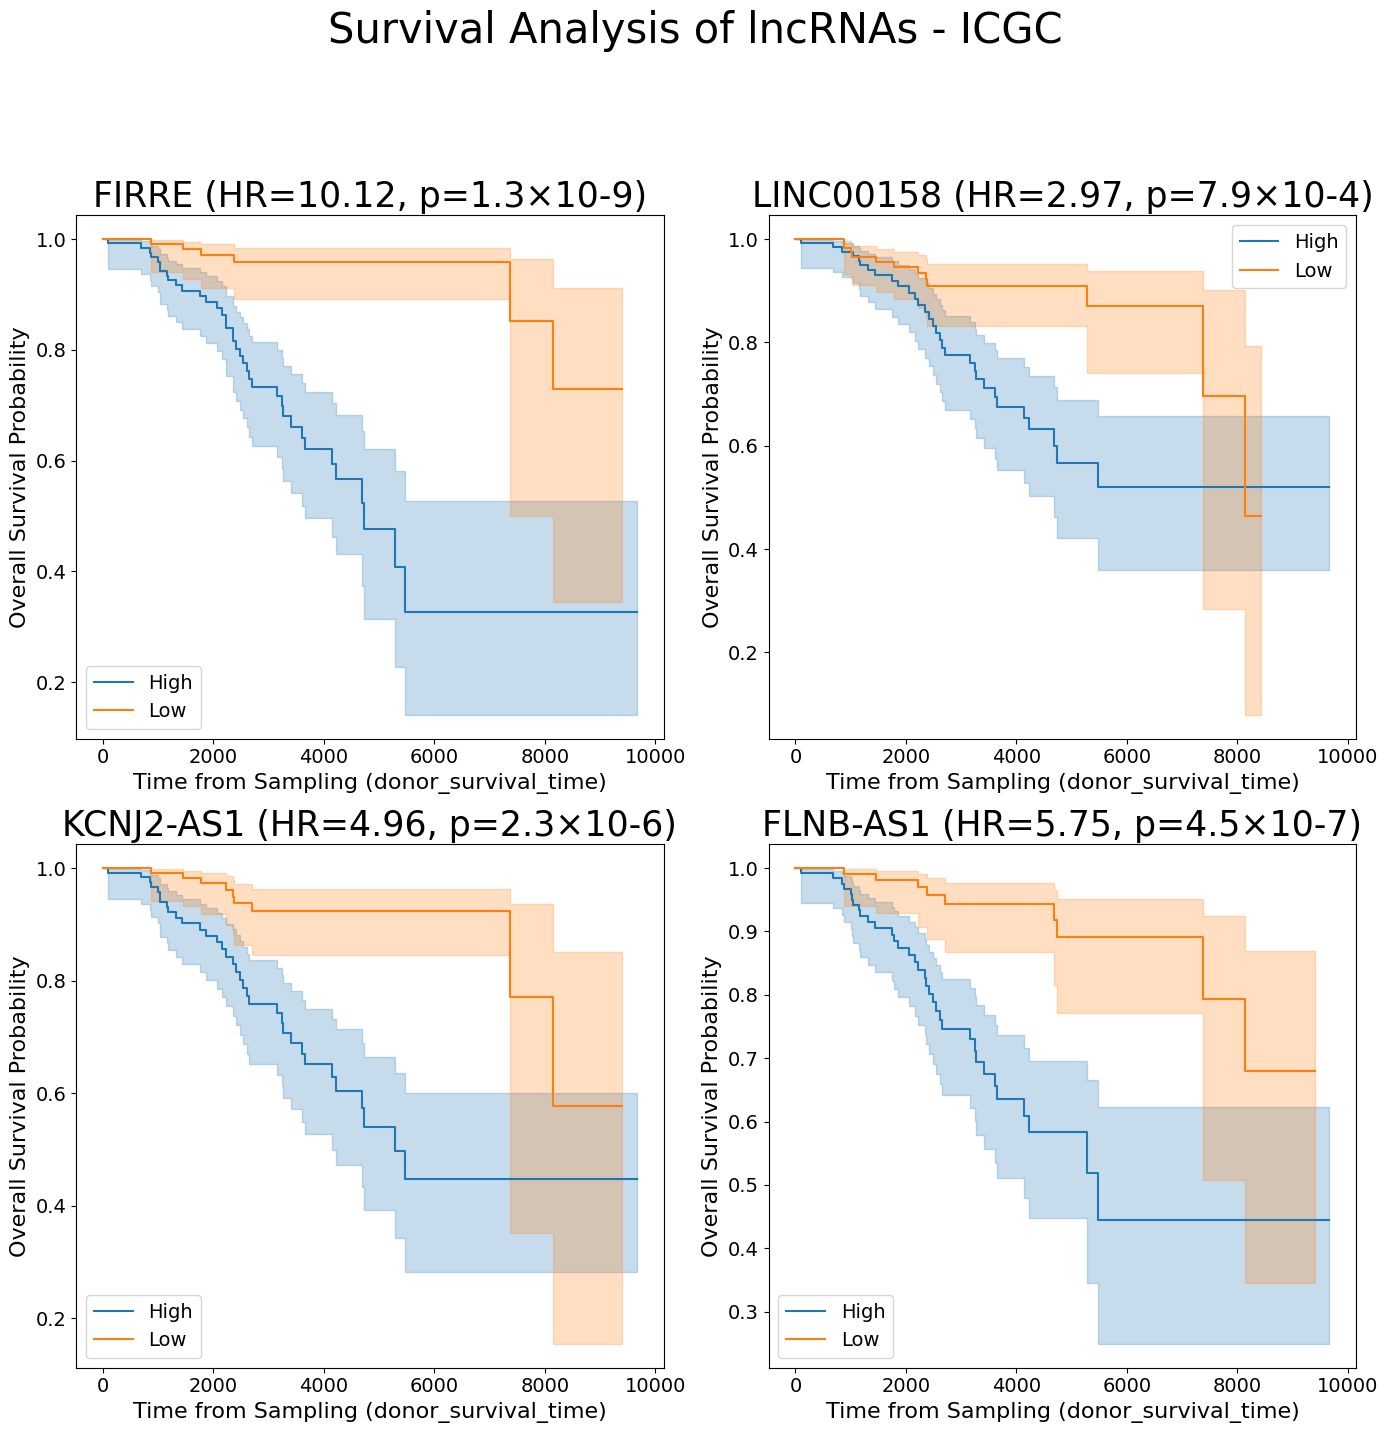

In [9]:
# Activity ICGC with all genes
genes = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "FLNB-AS1_NC"]

kaplan_meier_plots(
    clinical_file="../../../data/ICGC/clinical_info.csv",
    expr_file="../../../data/ICGC/activity_matrix_pvalfilt.csv",
    genes=genes,
    output_file="../../figures/KaplanMeier_OS_all_genes_ICGC_activity.png",
    split_method="median",
    fig_title="Survival Analysis of lncRNAs - ICGC",
    time_col="donor_survival_time"
)

In [10]:
## Combine all critical lncRNAs into one KaplanMeier plot

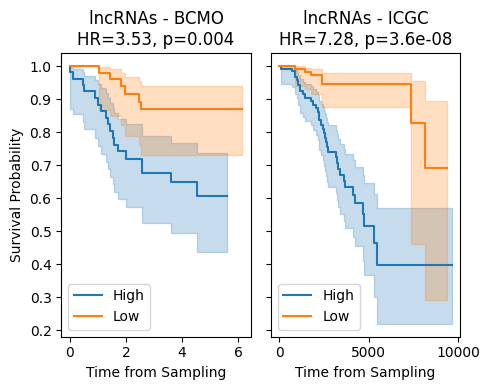

In [11]:
# --------------------------
# Helper function to create KM curve
# --------------------------
def km_curve(data, rna_cols, time_col, event_col, title, ax):
    # Combined score & group
    data["combined_score"] = data[rna_cols].sum(axis=1)
    data["combined_group"] = np.where(data["combined_score"] > data["combined_score"].median(), "High", "Low")

    # Log-rank test
    high = data[data["combined_group"]=="High"]
    low = data[data["combined_group"]=="Low"]
    results = logrank_test(high[time_col], low[time_col],
                           event_observed_A=high[event_col],
                           event_observed_B=low[event_col])
    pval = results.p_value
    pval_str = f"{pval:.3f}" if pval >= 0.001 else f"{pval:.1e}"

    # Cox PH for HR
    cox_df = data[[time_col, event_col, "combined_group"]].copy()
    cox_df["combined_group_num"] = cox_df["combined_group"].map({"Low":0, "High":1})
    cph = CoxPHFitter()
    cph.fit(cox_df[[time_col, event_col, "combined_group_num"]],
            duration_col=time_col, event_col=event_col)
    hr = cph.hazard_ratios_["combined_group_num"]
    hr_ci = cph.confidence_intervals_.loc["combined_group_num"].tolist()
    hr_ci_str = f"{hr_ci[0]:.2f}-{hr_ci[1]:.2f}"

    # Plot KM
    kmf = KaplanMeierFitter()
    for label, group in data.groupby("combined_group"):
        kmf.fit(group[time_col], group[event_col], label=label)
        kmf.plot_survival_function(ax=ax)
    
    ax.set_title(f"{title}\nHR={hr:.2f}, p={pval_str}", fontsize=12)
    ax.set_xlabel("Time from Sampling")
    ax.set_ylabel("Survival Probability")

# --------------------------
# Step 1: Load datasets
# --------------------------
# BCMO
clinical_bcmo = pd.read_csv("../../../data/BCMO/clinical_info.csv")
expr_bcmo = pd.read_csv("../../../data/BCMO/activity_matrix_pvalfilt.csv", index_col=0)
rna_bcmo = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "FLNB-AS1_NC"]
expr_bcmo = expr_bcmo.loc[rna_bcmo].T
expr_bcmo.index.name = "Sample_ID"
data_bcmo = clinical_bcmo.merge(expr_bcmo, on="Sample_ID")

# ICGC
clinical_icgc = pd.read_csv("../../../data/ICGC/clinical_info.csv")
expr_icgc = pd.read_csv("../../../data/ICGC/activity_matrix_pvalfilt.csv", index_col=0)
rna_icgc = ["FIRRE_NC", "LINC00158_NC", "KCNJ2-AS1_NC", "FLNB-AS1_NC"]
expr_icgc = expr_icgc.loc[rna_icgc].T
expr_icgc.index.name = "Samples"
data_icgc = clinical_icgc.merge(expr_icgc, on="Samples")

# Preprocess ICGC clinical
data_icgc["donor_vital_status_num"] = data_icgc["donor_vital_status"].map({"alive":0, "deceased":1})
data_icgc["donor_survival_time"] = pd.to_numeric(data_icgc["donor_survival_time"], errors='coerce')
data_icgc = data_icgc.dropna(subset=["donor_survival_time", "donor_vital_status_num"] + rna_icgc)

# --------------------------
# Step 2: Plot 1x2 multipanel
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(5,4), sharey=True)

km_curve(data_bcmo, rna_bcmo, "OS.from.sampling", "died", "lncRNAs - BCMO", axes[0])
km_curve(data_icgc, rna_icgc, "donor_survival_time", "donor_vital_status_num", "lncRNAs - ICGC", axes[1])

plt.tight_layout()
plt.savefig("../../figures/KM_BCMO_ICGC_activity_1x2.png", dpi=300, bbox_inches='tight')
plt.show()


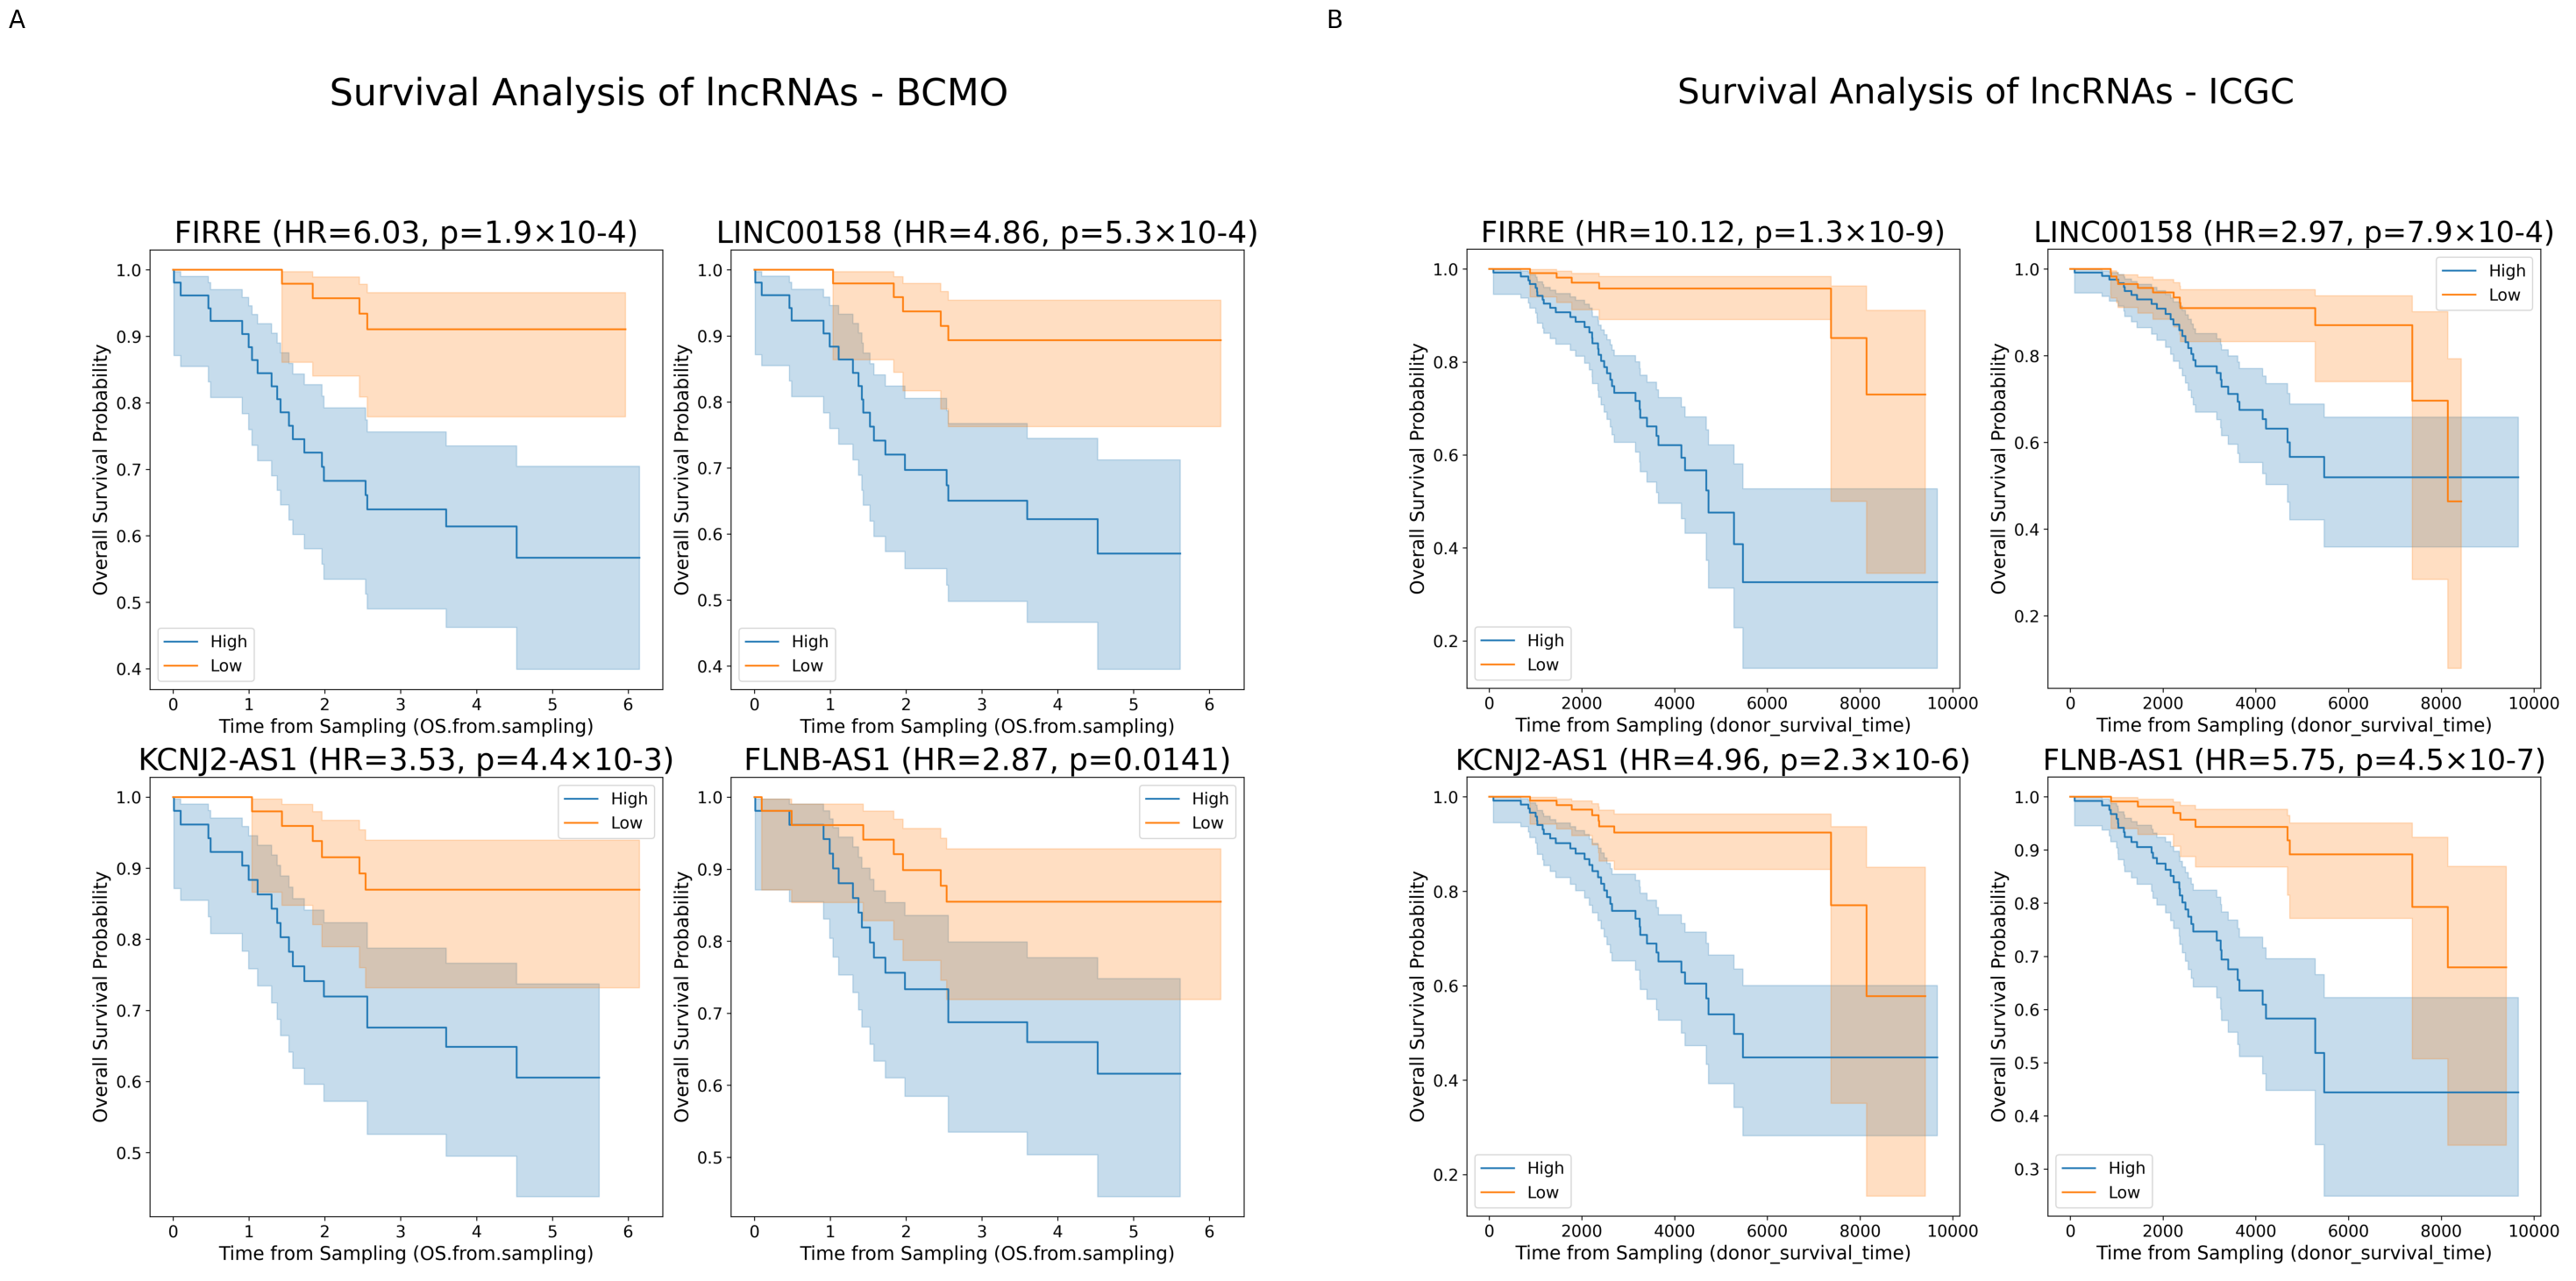

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

# Paths to your existing Kaplan-Meier plots
bcmo_path = "../../figures/KaplanMeier_OS_all_genes_BCMO_activity.png"
icgc_path = "../../figures/KaplanMeier_OS_all_genes_ICGC_activity.png"

# Open images
img_bcmo = Image.open(bcmo_path)
img_icgc = Image.open(icgc_path)

# Create a figure with 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(30, 15))

# BCMO panel
axes[0].imshow(img_bcmo)
axes[0].axis('off')  # Hide axes
axes[0].text(-0.05, 1.05, 'A', transform=axes[0].transAxes, 
             fontsize=20, va='top', ha='right')

# ICGC panel
axes[1].imshow(img_icgc)
axes[1].axis('off')
axes[1].text(-0.05, 1.05, 'B', transform=axes[1].transAxes, 
             fontsize=20, va='top', ha='right')

# Add a main title for the multipanel figure
#fig.suptitle("Kaplan Meier plot for critical lncRNAs", fontsize=22, fontweight='bold')

# Adjust layout to prevent title overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save combined figure
plt.savefig("../../figures/Multipanel_KaplanMeier_1x2.png", dpi=300)
plt.show()